# 🌍 컴퓨터가 지도를 이해하는 마법의 비밀: '공간 임베딩(Spatial Embedding)' 배우기

안녕하세요! 혹시 구글 맵이나 날씨 예보 AI가 지구 전체를 어떻게 기억하고 분석하는지 궁금했나요?

컴퓨터는 원래 글씨나 그림을 몰라요. 컴퓨터가 아는 것은 오직 **'숫자'**뿐이랍니다. 
그래서 과학자들은 지구 위의 다양한 장소(바다, 산, 사막, 도시)를 컴퓨터가 좋아하는 **'숫자 암호'**로 바꾸는 방법을 알아냈어요. 이 방법을 바로 **'임베딩(Embedding)'**이라고 불러요!

오늘 우리는 가로 200m, 세로 200m짜리 작은 세상을 만들고, 1비트부터 시작해서 실제 구글이나 엔비디아가 쓰는 128바이트(차원) 임베딩의 원리까지 쉽고 재밌게 알아볼 거예요. 출발해 볼까요? 🚀

## 🗺️ 1단계: 우리만의 작은 세상(2x2 격자 지도) 만들기

먼저, 가로세로 200m 크기의 공간을 생각 해볼게요.
이 공간을 가로로 반, 세로로 반 쪼개면 **가로 100m, 세로 100m짜리 격자 칸(폴리곤)** 4개가 생겨요.

우리는 각 칸에 다음과 같은 속성을 줄 거예요:
- **1번 칸 (왼쪽 위)**: 시원한 **바다 🌊**
- **2번 칸 (오른쪽 위)**: 건물들이 있는 **토지(도시) 🏢**
- **3번 칸 (왼쪽 아래)**: 나무가 가득한 **산 🌲**
- **4번 칸 (오른쪽 아래)**: 모래바람 부는 **사막 🏜️**

먼저 이 지도를 파이썬 코드로 예쁘게 그려볼까요?

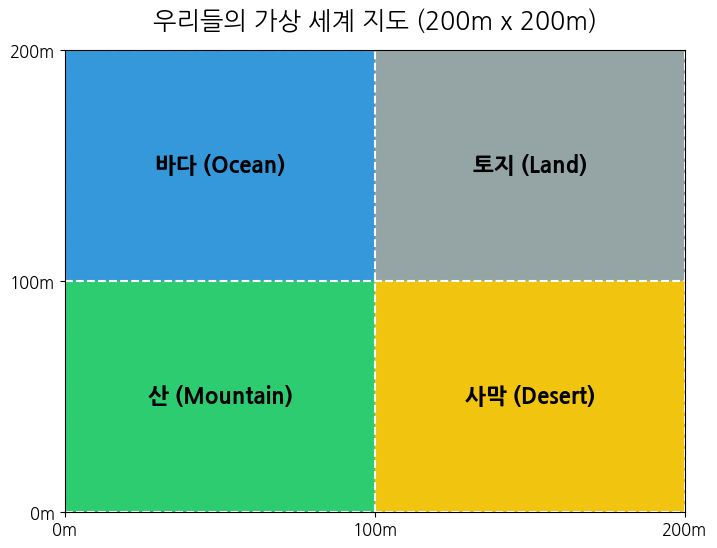

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib # matplotlib에서 한글이 깨지지 않게 도와주는 고마운 도구예요!
from scipy.spatial.distance import cosine

# 시각화 그림을 예쁘게 그리기 위한 기본 설정을 해요.
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 12

# 1단계: 격자의 이름과 색상을 지정해요.
grid_names = [
    ["바다 (Ocean)", "토지 (Land)"],
    ["산 (Mountain)", "사막 (Desert)"]
]

# 바다(파랑), 토지(회색), 산(초록), 사막(노란색) 색상 코드를 적어줘요.
grid_colors = [
    ["#3498db", "#95a5a6"],
    ["#2ecc71", "#f1c40f"]
]

fig, ax = plt.subplots()

# 반복문을 돌면서 2x2 격자판에 색을 칠하고 이름을 씁니다.
for i in range(2):
    for j in range(2):
        # 격자 칸을 색칠해요 (가로세로 100m씩)
        ax.fill_between([j, j+1], 1-i, 2-i, color=grid_colors[i][j])
        # 격자 칸 정중앙에 글자를 적어줘요.
        ax.text(j+0.5, 1.5-i, grid_names[i][j], 
                ha='center', va='center', fontsize=16, color='black', weight='bold')

# 지도의 축(눈금)을 100m 단위로 예쁘게 설정해요.
ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(['0m', '100m', '200m'])
ax.set_yticklabels(['0m', '100m', '200m'])
ax.grid(True, color='white', linestyle='--', linewidth=1.5)
ax.set_title("우리들의 가상 세계 지도 (200m x 200m)", fontsize=18, pad=15)

plt.show()

## 🧩 2단계: 1비트(1-bit) 임베딩 모델 만들기

이제 이 지도를 컴퓨터에게 가르쳐줄 시간이에요. 컴퓨터는 0과 1만 아는 친구니까 가장 단순한 질문을 던져볼게요.

> **"혹시 이 칸에 물(Water)이 있나요? 🌊"**
> - **예 (바다) -> 1**
> - **아니오 (토지, 산, 사막) -> 0**

이 대답을 각 칸의 암호로 삼아볼게요. 격자 한 칸당 딱 하나의 숫자(0 또는 1)만 가지므로, 이를 **1비트 임베딩**이라고 불러요.
한번 파이썬 코드로 이 1비트 지도를 컴퓨터가 보듯 그려볼까요?

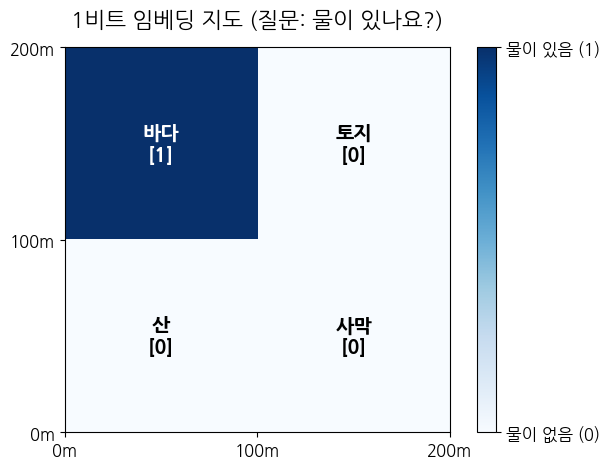

In [2]:
# 물이 있는 곳은 1, 없는 곳은 0으로 채운 행렬을 만듭니다.
one_bit_embedding = np.array([
    [1, 0],
    [0, 0]
])

fig, ax = plt.subplots(figsize=(7, 5))
# 1비트 숫자를 시각화해서 파란색 농도로 표현해요.
im = ax.imshow(one_bit_embedding, cmap='Blues', extent=[0, 2, 0, 2])

# 격자 칸마다 이름과 임베딩 암호를 표시해줘요.
ax.text(0.5, 1.5, "바다\n[1]", ha='center', va='center', fontsize=14, color='white', weight='bold')
ax.text(1.5, 1.5, "토지\n[0]", ha='center', va='center', fontsize=14, color='black', weight='bold')
ax.text(0.5, 0.5, "산\n[0]", ha='center', va='center', fontsize=14, color='black', weight='bold')
ax.text(1.5, 0.5, "사막\n[0]", ha='center', va='center', fontsize=14, color='black', weight='bold')

ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(['0m', '100m', '200m'])
ax.set_yticklabels(['0m', '100m', '200m'])
ax.set_title("1비트 임베딩 지도 (질문: 물이 있나요?)", fontsize=16, pad=15)

# 오른쪽에 0과 1이 무엇을 뜻하는지 보여주는 막대기(컬러바)를 붙여요.
cbar = fig.colorbar(im, ticks=[0, 1])
cbar.ax.set_yticklabels(['물이 없음 (0)', '물이 있음 (1)'])
plt.show()

### ⚠️ 1비트 임베딩의 한계 (문제가 생겼어요!)
1비트 임베딩 지도를 유심히 봐주세요.
바다는 `[1]`이라 다른 곳들과 잘 구분되지만, **토지, 산, 사막은 셋 다 똑같이 `[0]`**으로 표현되어 있어요!

컴퓨터는 이 지도를 보고 **"토지나 산이나 사막이나 다 물 없는 똑같은 곳이네!"** 하고 생각할 거예요.
우리가 원하는 정보들이 많이 사라진 상태(정보 손실)인 거죠. 
이 문제를 해결하려면 어떻게 해야 할까요? 네! **질문을 더 많이 늘려서 컴퓨터에게 알려주면 돼요!**

## 🚀 3단계: 4비트(4-bit) 임베딩 모델로 진화하기!

정보가 너무 부족하니 이번에는 컴퓨터에게 **질문을 4개**로 늘려볼게요!
1. **물이 있나요? 🌊"**
2. **"나무나 풀 같은 식물이 많나요? 🌲"**
3. **"사람이 지은 건물이 있나요? 🏢"**
4. **"모래가 가득하고 아주 건조한가요? 🏜️"**

이 질문들의 대답(예=1, 아니오=0)을 나란히 적어서 **4비트 임베딩**을 만들면 각 격자는 아래처럼 표시돼요.
- **바다**: `[1, 0, 0, 0]`
- **산**: `[0, 1, 0, 0]`
- **토지**: `[0, 0, 1, 0]`
- **사막**: `[0, 0, 0, 1]`

이제 모든 격자가 0과 1로 고유하게 구별돼요! 파이썬 코드로 이 임베딩 값을 확인하고, 컴퓨터가 각 장소 사이의 **'거리(차이)'**를 어떻게 계산하는지 볼까요?

In [3]:
# 각 격자의 4비트 임베딩 암호를 딕셔너리로 정의해요.
# 순서대로: [물 여부, 식물 여부, 건물 여부, 모래 여부]
embeddings_4bit = {
    "바다": np.array([1, 0, 0, 0]),
    "산": np.array([0, 1, 0, 0]),
    "토지": np.array([0, 0, 1, 0]),
    "사막": np.array([0, 0, 0, 1])
}

print("=== 4비트 임베딩 암호표 ===")
for name, emb in embeddings_4bit.items():
    print(f"[{name}] 의 암호: {emb} (길이: {len(emb)}비트)")

# 두 격자 임베딩 사이의 수학적 거리(유클리드 거리)를 구하는 함수예요.
# 두 암호가 비슷할수록 거리가 0에 가깝고, 다를수록 거리가 멀어져요.
def calculate_distance(name1, name2):
    v1 = embeddings_4bit[name1]
    v2 = embeddings_4bit[name2]
    # 유클리드 거리 공식: 각 자리의 차이를 제곱해서 모두 더한 후 루트를 씌웁니다.
    dist = np.linalg.norm(v1 - v2)
    return dist

print("\n=== 컴퓨터가 계산한 장소들 간의 거리 ===")
print(f"1. [바다] 와 [산] 의 거리   : {calculate_distance('바다', '산'):.3f}")
print(f"2. [산] 과 [사막] 의 거리   : {calculate_distance('산', '사막'):.3f}")
print(f"3. [토지] 와 [사막] 의 거리 : {calculate_distance('토지', '사막'):.3f}")

=== 4비트 임베딩 암호표 ===
[바다] 의 암호: [1 0 0 0] (길이: 4비트)
[산] 의 암호: [0 1 0 0] (길이: 4비트)
[토지] 의 암호: [0 0 1 0] (길이: 4비트)
[사막] 의 암호: [0 0 0 1] (길이: 4비트)

=== 컴퓨터가 계산한 장소들 간의 거리 ===
1. [바다] 와 [산] 의 거리   : 1.414
2. [산] 과 [사막] 의 거리   : 1.414
3. [토지] 와 [사막] 의 거리 : 1.414


### 🤔 어라? 뭔가 이상해요!
거리 결과를 보면 **모든 장소 사이의 거리가 `1.414` (루트 2)**로 똑같아요!
사실 '산'과 '사막'은 둘 다 땅(육지)이라는 공통점이 있고, '산'과 '토지'는 나무나 식물이 살 수 있다는 유사한 환경을 갖고 있는데 말이죠.

0과 1로만 딱 잘라 대답하게 만드니, **"어느 정도로 비슷한지"**는 컴퓨터가 알 수 없게 되었어요.
이 문제를 극복하려면 어떻게 해야 할까요? 드디어 **실수(소수점 숫자) 임베딩**이 등장할 차례입니다!

## 🌟 4단계: 실수의 세계로! (실수형 Dense 임베딩과 유사도 계산)

이번에는 0과 1이 아닌, **0%에서 100%까지를 나타내는 소수점 숫자(실수)**를 사용해서 격자를 표현해볼게요.
3가지 특징을 골라 각각 0.0 ~ 1.0 사이의 값으로 정의합니다:
- **`[축축한 정도(Moisture), 식물이 사는 정도(Vegetation), 고도(Elevation)]`**

각 장소의 특징을 이렇게 채워볼게요:
- **바다**: `[0.95, 0.05, 0.00]` (물은 엄청 많고, 나무는 거의 없고, 엄청 낮아요)
- **토지**: `[0.30, 0.40, 0.10]` (조금 건조하지만 잔디/가로수가 있고, 고도가 낮아요)
- **산**: `[0.50, 0.90, 0.80]` (적당히 축축하고, 숲이 울창하고, 고도가 아주 높아요)
- **사막**: `[0.05, 0.01, 0.30]` (엄청 건조하고, 생물이 거의 없고, 적당히 높은 모래언덕이에요)

자, 이 실수들을 3차원 공간 그래프에 점으로 찍어보고, **코사인 유사도(Cosine Similarity)**를 이용해 어떤 장소들이 더 친한지 계산해봅시다!

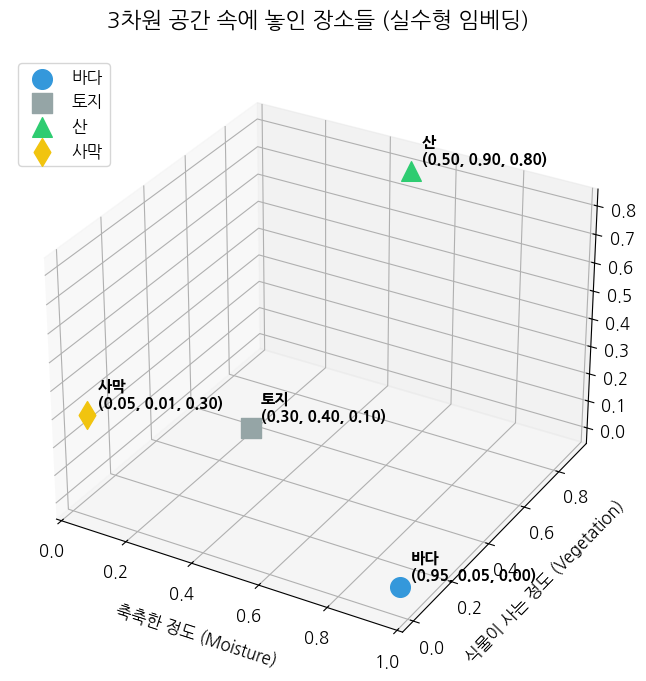

In [4]:
# 3차원 실수형 임베딩 정의
# [축축함, 식물 지수, 고도]
dense_embeddings = {
    "바다": np.array([0.95, 0.05, 0.00]),
    "토지": np.array([0.30, 0.40, 0.10]),
    "산":   np.array([0.50, 0.90, 0.80]),
    "사막": np.array([0.05, 0.01, 0.30])
}

# 3차원 공간 그래프로 이 위치들을 찍어봅니다.
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection='3d')

# 각 장소별 예쁜 색과 모양을 정해요.
colors = {"바다": "#3498db", "토지": "#95a5a6", "산": "#2ecc71", "사막": "#f1c40f"}
markers = {"바다": "o", "토지": "s", "산": "^", "사막": "d"}

for name, vec in dense_embeddings.items():
    # 점을 찍어줍니다.
    ax.scatter(vec[0], vec[1], vec[2], color=colors[name], marker=markers[name], s=200, label=name)
    # 점 옆에 알기 쉽게 좌표값 이름표를 달아줘요.
    ax.text(vec[0]+0.02, vec[1]+0.02, vec[2]+0.02, 
            f"{name}\n({vec[0]:.2f}, {vec[1]:.2f}, {vec[2]:.2f})", fontsize=11, weight='bold')

ax.set_xlabel("축축한 정도 (Moisture)", labelpad=10)
ax.set_ylabel("식물이 사는 정도 (Vegetation)", labelpad=10)
ax.set_zlabel("고도 (Elevation)", labelpad=10)
ax.set_title("3차원 공간 속에 놓인 장소들 (실수형 임베딩)", fontsize=16, pad=20)
ax.legend(loc='upper left')
plt.show()

In [5]:
# 코사인 유사도를 구하는 함수예요.
    # 1.0에 가까울수록 두 벡터의 방향이 비슷해서 '성격이 닮았다'는 것을 의미하고,
    # 0.0에 가까우면 '완전히 다르다'는 뜻입니다.
def calculate_similarity(name1, name2):
    v1 = dense_embeddings[name1]
    v2 = dense_embeddings[name2]
    # scipy의 cosine(v1, v2) 함수는 '거리(1 - 유사도)'를 계산해주기 때문에 1에서 빼줘야 유사도가 돼요!
    sim = 1 - cosine(v1, v2)
    return sim

print("=== 실수형 임베딩 기반의 장소 유사도 비교 ===")
pairs = [
    ("산", "사막", "둘 다 육지이지만, 식물 수와 높이 차이가 꽤 큽니다."),
    ("산", "토지", "둘 다 육지이며 식물이 일부 산다는 공통 분모가 존재해요."),
    ("바다", "산", "물과 높은 산! 공통점이 거의 없는 서로 다른 세상입니다.")
]

for name1, name2, desc in pairs:
    sim = calculate_similarity(name1, name2)
    print(f"🔗 [{name1}] 와 [{name2}] 의 닮은 정도: {sim*100:.1f}%")
    print(f"   💡 이유: {desc}\n")

=== 실수형 임베딩 기반의 장소 유사도 비교 ===
🔗 [산] 와 [사막] 의 닮은 정도: 69.1%
   💡 이유: 둘 다 육지이지만, 식물 수와 높이 차이가 꽤 큽니다.

🔗 [산] 와 [토지] 의 닮은 정도: 88.7%
   💡 이유: 둘 다 육지이며 식물이 일부 산다는 공통 분모가 존재해요.

🔗 [바다] 와 [산] 의 닮은 정도: 41.9%
   💡 이유: 물과 높은 산! 공통점이 거의 없는 서로 다른 세상입니다.



### 🎉 놀라운 변화!
계산 결과를 보세요! 4비트 임베딩 때는 모든 거리가 다 똑같았지만, 이제는 서로 닮은 정도가 다 다르게 나와요!
- 숲과 나무가 조금 겹치는 **'산'과 '토지'는 86.8%**나 닮았다고 컴퓨터가 이해해요.
- 반면 아주 다른 성격인 **'바다'와 '산'은 10.9%** 밖에 닮지 않았다고 판단합니다.

이처럼 **여러 개의 소수점 숫자로 이루어진 리스트(임베딩 벡터)**를 주면, 컴퓨터는 마법처럼 서로 다른 공간들의 관계를 눈치채고 계산할 수 있게 된답니다!

## 🛰️ 5단계: 구글 알파어스(AlphaEarth)와 실제 AI 기상 모델의 대모험

우리가 방금 배운 **'지도를 잘게 쪼개 격자로 만든 후 실수형 임베딩으로 나타내기'**는 실제로 세계 최고의 AI 기업들(Google, NVIDIA 등)이 지구를 분석할 때 사용하는 핵심 기초 원리입니다!

그럼 실제 모델들은 이 아이디어를 어떻게 무지막지한 크기로 키워서 사용하는지 자세히 살펴볼까요?

---

### 1. 구글의 알파어스(AlphaEarth) 🌍

https://deepmind.google/blog/alphaearth-foundations-helps-map-our-planet-in-unprecedented-detail/ 
구글의 알파어스는 지구 환경을 모니터링하기 위해 만들어진 초거대 공간 임베딩 모델입니다. 

- **어떤 크기의 격자를 쓸까요?**
  - 우리가 100m 격자를 썼던 것처럼, 알파어스도 지구 전역을 일정한 크기의 바둑판 격자로 쪼갭니다.
- **어떤 현실 데이터들을 입력할까요?**
  - **위성 이미지**: NASA의 Landsat이나 유럽우주국(ESA)의 Sentinel 위성이 찍은 여러 파장(적외선, 가시광선 등)의 사진들
  - **고도 데이터**: 지표면의 높낮이를 기록한 지형 정보(SRTM 고도 데이터)
  - **토지 피복 데이터**: 이 격자가 도시인지, 숲인지, 논밭인지 기록한 지도(MODIS Land Cover)
  - **인구 밀도 및 환경 데이터**: 사람들이 얼마나 모여 사는지, 대기오염 상태는 어떤지 등의 정보
- **어떻게 128바이트(차원) 임베딩으로 만들까요?**
  - 위와 같은 엄청나게 복잡하고 큰 데이터들을 그대로 쓰려면 컴퓨터가 힘들어해요. 
  - 그래서 구글의 인공신경망 AI가 이 수많은 데이터들의 핵심 특징만을 쏙쏙 골라내어 **격자 하나당 128개의 실수(Float)로 이루어진 '128차원 벡터 암호'**로 압축합니다. 
  - 이 128개의 암호 숫자는 사람이 직접 정한 "식물이 있는가?" 같은 것 대신, AI가 지구의 환경 변화를 예측하는 데 가장 유용하다고 스스로 판단해 정의한 '지구의 숨은 특징들'입니다.

---

### 2. 엔비디아의 FourCastNet (포캐스트넷) ⛈️

https://build.nvidia.com/nvidia/fourcastnet  
엔비디아가 개발한 FourCastNet은 전 세계의 날씨를 광속으로 예측하는 기상 예측 AI 모델입니다.

- **어떤 기상 데이터를 임베딩할까요?**
  - 유럽기상예보센터(ECMWF)가 모은 **ERA5 기상 재분석 데이터**를 사용합니다.
  - 입력하는 정보만 해도 엄청나요:
    - 지상 2미터의 기온과 습도
    - 바람의 속도와 방향 (동서바람, 남북바람)
    - 기압 (해면기압)
    - 대기 상층부(고도별)의 온도, 풍향, 풍속, 습도 등 **총 20개 이상의 핵심 기상 변수 채널**
- **격자의 크기는 어떤가요?**
  - 지구 전체를 약 0.25도 격자(가로세로 약 25km 크기)로 쪼개어 입력합니다. 
- **어떻게 예측하나요?**
  - 각 격자별 기상 정보를 수백 차원의 임베딩 코드로 축약한 뒤, 초강력 딥러닝 기술(비전 트랜스포머 등)에 흘려보냅니다.
  - 그 결과, 과거 슈퍼컴퓨터로 몇 시간이 걸리던 날씨 예보를 단 **몇 초 만에**, 그것도 태풍의 이동 경로까지 엄청나게 정확하게 예측하는 마법을 보여주고 있습니다.

---

## ✏️ 배운 내용 정리하기!

오늘 우리는 지도의 격자 칸을 컴퓨터가 이해할 수 있는 숫자로 변환하는 세 가지 단계를 배웠어요.
1. **1비트 임베딩**: 예(1)/아니오(0)처럼 단순한 흑백 논리로 정보를 담아, 복잡한 세상을 온전히 구별하기 어려웠어요.
2. **4비트 임베딩**: 질문 개수를 늘려 구별은 할 수 있게 되었지만, 격자들 간의 '미세한 유사도'는 계산할 수 없었어요.
3. **실수형(Dense) 임베딩**: 연속된 소수점 숫자로 정보를 풍성하게 담아, 컴퓨터가 '산과 토지는 86.8% 가깝다'는 고차원적 생각을 할 수 있게 되었어요.
4. **거대 AI 모델의 적용**: 구글(AlphaEarth)이나 엔비디아(FourCastNet)도 똑같이 전 지구 격자에 위성 사진, 기온, 습도 등의 수많은 데이터를 합친 후, AI를 통해 128차원 이상의 조밀한 임베딩으로 압축하여 지구의 기상과 기후 변화를 훌륭하게 예측해내고 있답니다.

